# Benchmark 1: Spherical Harmonics

- *Authors*: Danilo Aballay and Elwin van 't Wout
- *Affiliation*: Pontificia Universidad Católica de Chile
- *Date:* 25 May 2026
- *Description*: This benchmark considers a spherical scatterer with a piecewise constant material density. The numerical results from the VSIE and BEM are compared to the analytical solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from benchmarks import analytical_solution, VSIE_solve, bempp_solve, get_bempp_pressure
from parameters import PARAMETERS

In [2]:

def matrix_linf_norm(vec, shape):
    return np.linalg.norm(np.real(vec).reshape(shape), ord=np.inf)

def run_benchmark(parameters, element_per_wavelength=8):
    pressure_vie, problem = VSIE_solve(element_per_wavelength, parameters)
    

    n_vox = round(problem.mesh.shape[0]**(1/3))
    points3D = problem.mesh.reshape((n_vox, n_vox, n_vox, 3))
    slice = points3D[:, :, n_vox//2, :]
    points = slice.reshape((-1, 3))
    pressure_vie3D = pressure_vie.reshape((n_vox, n_vox, n_vox))
    pressure_vie_slice = pressure_vie3D[:, :, n_vox//2].reshape((-1,))

    pressure_analytical = analytical_solution(points, parameters)

    x_bempp, grid = bempp_solve(element_per_wavelength, parameters)
    pressure_bempp = get_bempp_pressure(x_bempp, parameters, grid, points.T, n_vox, C=0.5)

    shape = (n_vox, n_vox)

    error_anal_l2 = np.linalg.norm(np.real(pressure_analytical))
    error_anal_linf = matrix_linf_norm(pressure_analytical, shape)

    error_abs_vie_l2 = np.linalg.norm(np.real(pressure_vie_slice) - np.real(pressure_analytical))
    error_abs_vie_linf = matrix_linf_norm(np.real(pressure_vie_slice) - np.real(pressure_analytical), shape)

    error_abs_bempp_l2 = np.linalg.norm(np.real(pressure_bempp) - np.real(pressure_analytical))
    error_abs_bempp_linf = matrix_linf_norm(np.real(pressure_bempp) - np.real(pressure_analytical), shape)

    error_rel_vie_l2 = error_abs_vie_l2 / error_anal_l2
    error_rel_vie_linf = error_abs_vie_linf / error_anal_linf
    error_rel_bempp_l2 = error_abs_bempp_l2 / error_anal_l2
    error_rel_bempp_linf = error_abs_bempp_linf / error_anal_linf

    data = {
        'solution_analytical': pressure_analytical,
        'solution_vie': pressure_vie_slice,
        'solution_bempp': pressure_bempp,
        'error_abs_vie_l2': error_abs_vie_l2,
        'error_abs_vie_linf': error_abs_vie_linf,
        'error_abs_bempp_l2': error_abs_bempp_l2,
        'error_abs_bempp_linf': error_abs_bempp_linf,
        'error_rel_vie_l2': error_rel_vie_l2,
        'error_rel_vie_linf': error_rel_vie_linf,
        'error_rel_bempp_l2': error_rel_bempp_l2,
        'error_rel_bempp_linf': error_rel_bempp_linf,
        'Nx': n_vox,
        'Ny': n_vox,
        'Nz': n_vox,
        'points': points,
    }

    return data



## Single benchmark

Let us perform a single benchmark with a fixed number of elements per wavelength.

In [4]:
"""
Singular test
"""

data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=5)

/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


/var/folders/n_/86gc5_ss68qf_7rmsgy_3hvw0000gn/T/ipykernel_12243/3693236233.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('seismic'),
/var/folders/n_/86gc5_ss68qf_7rmsgy_3hvw0000gn/T/ipykernel_12243/3693236233.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis'),


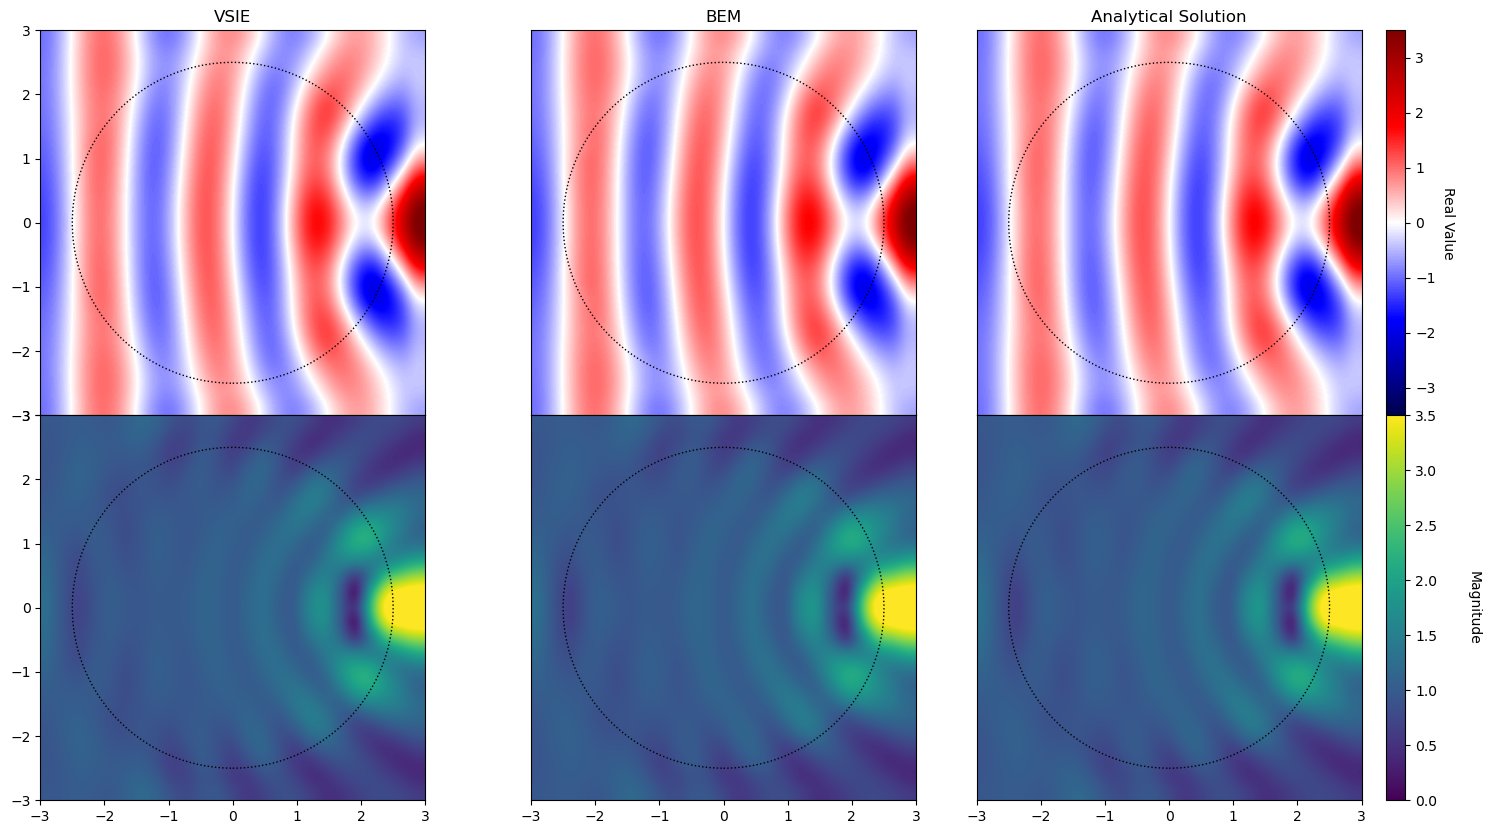

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(19,10))

xmin, xmax, ymin, ymax = -PARAMETERS["SIZE"]/2, PARAMETERS["SIZE"]/2, -PARAMETERS["SIZE"]/2, PARAMETERS["SIZE"]/2
radius = PARAMETERS["RADIUS"]

Nx = data_benchmark['Nx']
Ny = data_benchmark['Ny']

bem_sol = data_benchmark['solution_bempp'].reshape((Nx, Ny))
vie_sol = data_benchmark['solution_vie'].reshape((Nx, Ny))
analy_sol = data_benchmark['solution_analytical'].reshape((Nx, Ny))

info_plot_re = [
    (axs[0, 1], "BEM", np.real((bem_sol).T), [-3.5, 3.5]),
    (axs[0, 0], "VSIE", np.real((vie_sol).T), [-3.5, 3.5]),
    (axs[0, 2], "Analytical Solution", np.real((analy_sol).T), [-3.5, 3.5])
]
info_plot_ab = [
    (axs[1, 1], np.abs((bem_sol).T), [0, 3.5]),
    (axs[1, 0], np.abs((vie_sol).T), [0, 3.5]),
    (axs[1, 2], np.abs((analy_sol).T), [0, 3.5]),
]

for (ax, title, data, clims) in info_plot_re:
    ax.set_title(title)
    im = ax.imshow(data,
              extent=[xmin, xmax, ymin, ymax],
              cmap=plt.cm.get_cmap('seismic'), 
              interpolation='spline16',
              clim=clims)
    circle = plt.Circle((0., 0.), radius, color='black', fill=False,
                    linestyle=':')
    ax.add_artist(circle)
    ax.set_aspect('equal')

axs[0, 1].get_yaxis().set_visible(False)
axs[0, 2].get_yaxis().set_visible(False)

axs[0, 0].get_xaxis().set_visible(False)
axs[0, 1].get_xaxis().set_visible(False)
axs[0, 2].get_xaxis().set_visible(False)
    
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Real Value', rotation=-90, va="bottom")

for (ax, data, clims) in info_plot_ab:
    im = ax.imshow(data,
              extent=[xmin, xmax, ymin, ymax],
              cmap=plt.cm.get_cmap('viridis'), 
              interpolation='spline16',
              clim=clims)
    circle = plt.Circle((0., 0.), radius, color='black', fill=False,
                    linestyle=':')
    ax.add_artist(circle)
    ax.set_aspect('equal')

cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel('Magnitude', rotation=-90, labelpad=21.0, va="bottom")

axs[1, 1].get_yaxis().set_visible(False)
axs[1, 2].get_yaxis().set_visible(False)


plt.subplots_adjust(wspace=0, hspace=0)

In [5]:
print("Relative L2 error VIE: ", data_benchmark['error_rel_vie_l2'])
print("Relative Linf error VIE: ", data_benchmark['error_rel_vie_linf'])
print("Relative L2 error BEMPP: ", data_benchmark['error_rel_bempp_l2'])
print("Relative Linf error BEMPP: ", data_benchmark['error_rel_bempp_linf'])

Relative L2 error VIE:  0.02249301419539954
Relative Linf error VIE:  0.02235478555415262
Relative L2 error BEMPP:  0.012201694834776459
Relative Linf error BEMPP:  0.014137090370363592


## Convergence test

Let us perform a grid convergence test. Depending on computational resources, this may take minutes until hours. Eliminate or add experiments to the list of `elements_per_wavelength`.

In [ ]:
"""
Convergence test
"""

elements_per_wavelength = [5, 6, 7, 8, 9, 10, 11, 12]

data_convergence = defaultdict(list)

for element_per_wavelength in elements_per_wavelength:
    data_benchmark = run_benchmark(PARAMETERS, element_per_wavelength=element_per_wavelength)
    data_convergence['element_per_wavelength'].append(element_per_wavelength)
    data_convergence['N_elem'].append(data_benchmark['Nx'])
    data_convergence['error_rel_vie_l2'].append(data_benchmark['error_rel_vie_l2'])
    data_convergence['error_rel_vie_linf'].append(data_benchmark['error_rel_vie_linf'])
    data_convergence['error_rel_bempp_l2'].append(data_benchmark['error_rel_bempp_l2'])
    data_convergence['error_rel_bempp_linf'].append(data_benchmark['error_rel_bempp_linf'])
    print(f"Done with element_per_wavelength = {element_per_wavelength}")
    
    

/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 5



/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 6



/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


...

Done with points_per_element = 10



/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 11



/opt/anaconda3/envs/fembem2/lib/python3.10/site-packages/bempp/api/assembly/discrete_boundary_operator.py:639: SparseEfficiencyWarning: splu converted its input to CSC format
  solver = solver_interface(actual_mat)


Done with points_per_element = 12


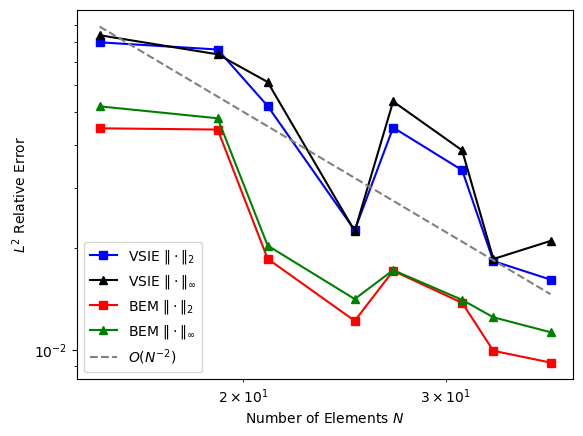

In [8]:

plt.loglog(data_convergence['N_elem'], data_convergence['error_rel_vie_l2'], 'bs-', label=r'VSIE $\|\cdot\|_2$') 
plt.loglog(data_convergence['N_elem'], data_convergence['error_rel_vie_linf'], 'k^-', label=r'VSIE $\|\cdot\|_\infty$')
plt.loglog(data_convergence['N_elem'], data_convergence['error_rel_bempp_l2'], 'rs-', label=r'BEM $\|\cdot\|_2$')
plt.loglog(data_convergence['N_elem'], data_convergence['error_rel_bempp_linf'], 'g^-', label=r'BEM $\|\cdot\|_\infty$')
plt.loglog(data_convergence['N_elem'], 20*np.array(data_convergence['N_elem'], dtype=np.float64)**(-2), label=r'$O(N^{-2})$', linestyle='--', color='gray')
plt.xlabel(r'Number of Elements $N$')
plt.ylabel(r'$L^2$ Relative Error')
plt.legend()

## Visualize convergence from data

The convergence test was performed on a powerful compute node and the results stored in the `data` folder. Let us load them and visualize the convergence plot.

In [2]:
num_vox = []
frb_err_bem = []
frb_err_vie = []
inf_err_bem = []
inf_err_vie = []

for i in range(5, 24):
    try:
        data_benchmark = np.load(f"data/benchmark_num_elem_{i}.npy", allow_pickle=True).item()
        num_vox.append(data_benchmark['num_elem'])
        frb_err_bem.append(data_benchmark['error_rel_bempp_l2'])
        frb_err_vie.append(data_benchmark['error_rel_vie_l2'])
        inf_err_bem.append(data_benchmark['error_rel_bempp_linf'])
        inf_err_vie.append(data_benchmark['error_rel_vie_linf'])
    except FileNotFoundError:
        print(f"File for N_elem={i} not found, skipping.")

num_vox = np.array(num_vox)
frb_err_bem = np.array(frb_err_bem)
frb_err_vie = np.array(frb_err_vie)
inf_err_bem = np.array(inf_err_bem)
inf_err_vie = np.array(inf_err_vie)

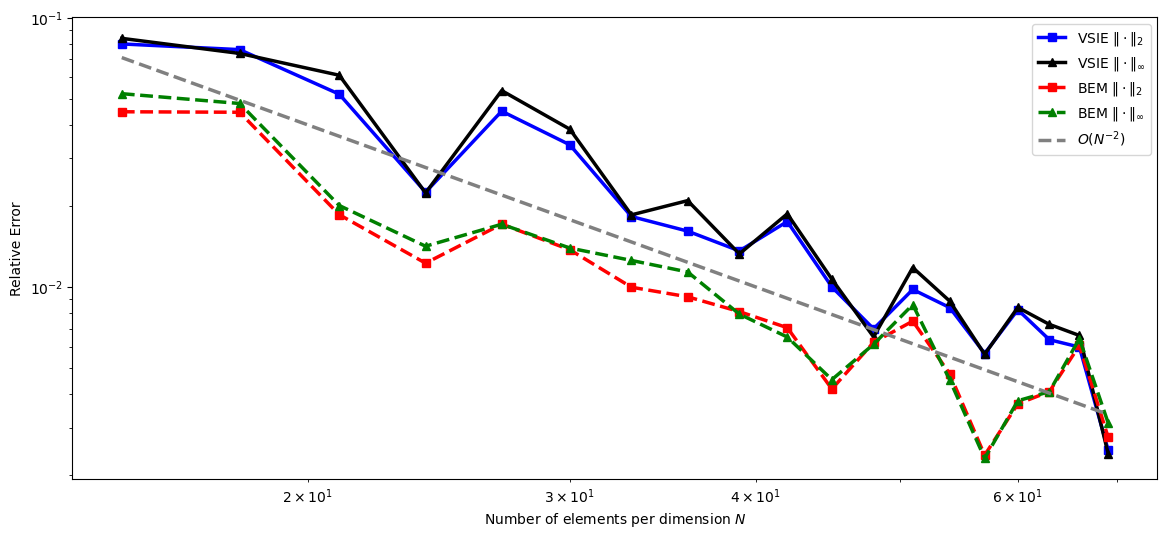

In [3]:
plt.figure(figsize=(14, 6))

dx = PARAMETERS["LAMBDA_EXT"]/num_vox
N_elem = (PARAMETERS["SIZE"] / dx)

plt.loglog(N_elem, frb_err_vie, 'bs-', label=r'VSIE $\|\cdot\|_2$', linewidth=2.5)
plt.loglog(N_elem, inf_err_vie, 'k^-', label=r'VSIE $\|\cdot\|_\infty$', linewidth=2.5)
plt.loglog(N_elem, frb_err_bem, 'rs--', label=r'BEM $\|\cdot\|_2$', linewidth=2.5)
plt.loglog(N_elem, inf_err_bem, 'g^--', label=r'BEM $\|\cdot\|_\infty$', linewidth=2.5)
plt.loglog(N_elem, 16*np.array(N_elem, dtype=np.float64)**(-2), label=r'$O(N^{-2})$', linestyle='--', color='gray', linewidth=2.5)
plt.xlabel(r'Number of elements per dimension $N$')
plt.ylabel(r'Relative Error')
plt.legend()
plt.show()